# Emotion Classification 
- with RNNs, LSTMs and GRUs

### classifying text into 6 emotions (sadness ,joy love, anger, fear, surprise)

### Import Libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#this library help to import dataset from  hugging face

from datasets import load_dataset

### 2 Load data set

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')

In [3]:
train_text=emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [4]:
label_names = emotion_dataset['train'].features['label'].names


In [5]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})

df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

In [6]:
print(df_train.head())

                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [7]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

# EDA (Exploratory Data Analysis)

<Axes: xlabel='label', ylabel='count'>

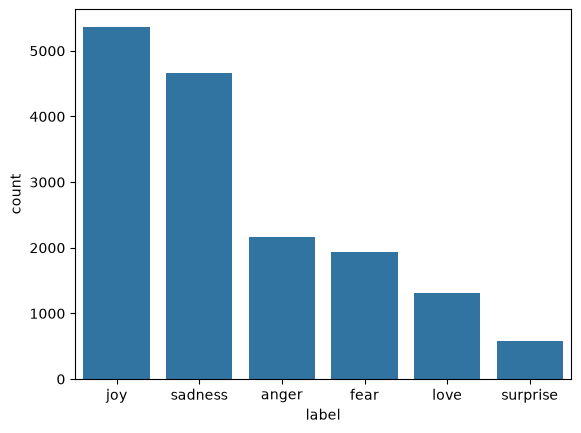

In [8]:
sns.countplot(x = 'label', data= df_train, order= df_train['label'].value_counts().index)

# Data Preprocessing - Using NLP
- tokenize text, pad sequences to max length 50, and convert labels into numpy array

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train['text']) #what it does it ..... "I love u" in this text each works is given rank

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen= 50, padding='post', truncating= 'post') #this is train X
padded_test_sequence = pad_sequences(test_sequence, maxlen= 50, padding='post', truncating= 'post')   # this is test X

train_labels = np.array(train_label) # this is train Y
test_labels = np.array(test_label)   # this is test Y
num_classes = len(np.unique(train_labels))

In [10]:
print(f"Vocabulary Size:{len(tokenizer.word_index)}")
print(f"Max Sentences Length: {padded_train_sequence.shape[1]}")

Vocabulary Size:15213
Max Sentences Length: 50


# Shared Training Utilities
- compute class weight mannually


In [11]:
from sklearn.utils import class_weight

In [12]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes= np.unique(train_labels),
    y= train_labels
)


In [13]:
class_weight_dict = dict(enumerate(class_weights))

- now apply early stoping

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### RNN

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50), #input length means how many words in a sentence
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.50),
    SimpleRNN(units=64),
    Dropout(0.50), # to prevent obverfitting we drop 50 percent of the layers
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\Nitro5\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.1693 - loss: 2.0187 - val_accuracy: 0.0345 - val_loss: 2.0166
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.1455 - loss: 1.8833 - val_accuracy: 0.0375 - val_loss: 1.8002
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1354 - loss: 1.8224 - val_accuracy: 0.0795 - val_loss: 1.8513
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1265 - loss: 1.8121 - val_accuracy: 0.0330 - val_loss: 1.8455
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.1363 - loss: 1.8034 - val_accuracy: 0.1365 - val_loss: 1.8052


In [43]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"Simple RNN test loss: {rnn_loss}")
print(f"RNN accuracy: {rnn_accuracy}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0375 - loss: 1.8002
Simple RNN test loss: 1.800212025642395
RNN accuracy: 0.03750000149011612


### LSTM

In [45]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50), #input length means how many words in a sentence
    LSTM(units=128, return_sequences=True),
    Dropout(0.50),
    LSTM(units=64),
    Dropout(0.50), # to prevent obverfitting we drop 50 percent of the layers
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\Nitro5\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [47]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.9194 - loss: 0.2498 - val_accuracy: 0.8590 - val_loss: 0.4924
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9318 - loss: 0.2133 - val_accuracy: 0.8590 - val_loss: 0.4889
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9381 - loss: 0.1875 - val_accuracy: 0.8645 - val_loss: 0.5022
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.9411 - loss: 0.1700 - val_accuracy: 0.8645 - val_loss: 0.4692
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.9509 - loss: 0.1455 - val_accuracy: 0.8735 - val_loss: 0.4832
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9576 - loss: 0.1385 - val_accuracy: 0.8710 - val_loss: 0.4566
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.9537 - loss: 0.1412 - val_accuracy: 0.8820 - val_loss: 0.5180
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9633 - loss: 0.1128 - 

In [53]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM test loss: {lstm_loss}")
print(f"LSTM accuracy: {lstm_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8710 - loss: 0.4566
LSTM test loss: 0.45656618475914
LSTM accuracy: 0.8709999918937683


### GRU

In [49]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50), #input length means how many words in a sentence
    LSTM(units=128, return_sequences=True),
    Dropout(0.50),
    LSTM(units=64),
    Dropout(0.50), # to prevent obverfitting we drop 50 percent of the layers
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\Nitro5\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [50]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - accuracy: 0.1297 - loss: 1.7955 - val_accuracy: 0.0800 - val_loss: 1.7878
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.1514 - loss: 1.7936 - val_accuracy: 0.2875 - val_loss: 1.7867
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.1581 - loss: 1.7941 - val_accuracy: 0.1435 - val_loss: 1.7840
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.1455 - loss: 1.7948 - val_accuracy: 0.2815 - val_loss: 1.7845
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.1782 - loss: 1.7921 - val_accuracy: 0.1115 - val_loss: 1.7956
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.1614 - loss: 1.7879 - val_accuracy: 0.1440 - val_loss: 1.7846


In [52]:
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU test loss: {gru_loss}")
print(f"GRU accuracy: {gru_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1435 - loss: 1.7840
GRU test loss: 1.7839515209197998
GRU accuracy: 0.14350000023841858


### Phase  Ranking and selection

In [57]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test_loss': [rnn_loss, lstm_loss, gru_loss],
    'Test_Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]  
}).sort_values(by='Test_Accuracy', ascending= False)

In [59]:
result_df

,Model,Test_loss,Test_Accuracy
1,LSTM,0.456566,0.8710
2,GRU,1.783952,0.1435
0,RNN,1.800212,0.0375


# Phase 2 - Advanced Bidirection GRU

In [61]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20


500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.8879 - loss: 0.3395 - val_accuracy: 0.9095 - val_loss: 0.2632
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9315 - loss: 0.1929 - val_accuracy: 0.9070 - val_loss: 0.2639
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.9514 - loss: 0.1376 - val_accuracy: 0.9135 - val_loss: 0.2688
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9648 - loss: 0.0954 - val_accuracy: 0.9180 - val_loss: 0.2578
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9720 - loss: 0.0798 - val_accuracy: 0.9255 - val_loss: 0.2784
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9762 - loss: 0.0688 - val_accuracy: 0.9165 - val_loss: 0.3117
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 92ms/step - accuracy: 0.9793 - loss: 0.0596 - val_accuracy: 0.9215 - val_loss: 0.2919


In [64]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss:{BiGRU_loss}")
print(f"BiGRU Loss:{BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9180 - loss: 0.2578
BiGRU Loss:0.25775185227394104
BiGRU Loss:0.9179999828338623


# Overall Evaluation Bias

- Final model Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1) #It helps to choose the output which has the max output


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


<Axes: >

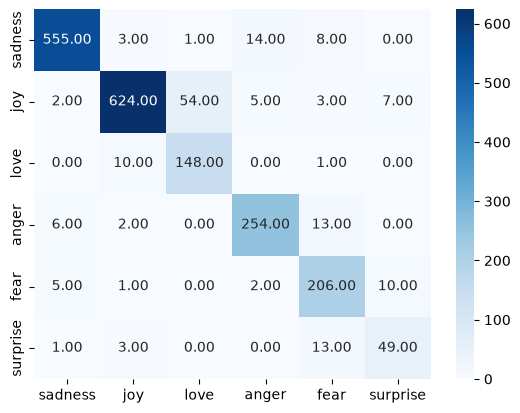

In [75]:

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, cmap='Blues', fmt='.2f', xticklabels=label_names, yticklabels=label_names)

# Final Predictions

In [85]:
sample_texts = [
    "I am feeling incredibly happy today, everything is going perfectly!",
    "I feel sad and completely empty after hearing the terrible news.",
    "I am extremely angry that they blamed me for something I didn't do.",
    "I feel scared and nervous whenever I have to walk home alone at night.",
    "I was completely surprised when my friends organized a birthday party for me.",
    "I am so excited about the trip we are going on next week!",
    "I feel calm and peaceful while sitting quietly near the lake."
]

sample_sequence = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequence, maxlen=50, padding= 'post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [86]:
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}\nPredicted emotion:{label_names[sample_predictions[i]]}")

Text: I am feeling incredibly happy today, everything is going perfectly!
Predicted emotion:joy
Text: I feel sad and completely empty after hearing the terrible news.
Predicted emotion:sadness
Text: I am extremely angry that they blamed me for something I didn't do.
Predicted emotion:anger
Text: I feel scared and nervous whenever I have to walk home alone at night.
Predicted emotion:fear
Text: I was completely surprised when my friends organized a birthday party for me.
Predicted emotion:surprise
Text: I am so excited about the trip we are going on next week!
Predicted emotion:joy
Text: I feel calm and peaceful while sitting quietly near the lake.
Predicted emotion:joy


# Save Model and Tokenizer

In [90]:
import joblib
import os 
import pickle

In [ ]:
# we will export BiGRU and tokenizer
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) 

In [92]:
# save our BiGRU model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.h5'))

In [94]:
# Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)